# Q3: Is attendance different in USA matches vs Mexico/Canada matches?

This analysis investigates whether average match attendance differs between matches played in the USA and matches played in Mexico or Canada.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## 1. Data Wrangling

First, the match dataset is loaded and the attendance variable is cleaned.

In [2]:
data = pd.read_csv("matches.csv")

print("Number of matches:", len(data))
print(data.head())

Number of matches: 104
         round  gameweek dayofweek        date start_time       home_team  \
0  Group stage       1.0       Thu  2026-06-11      13:00          Mexico   
1  Group stage       1.0       Thu  2026-06-11      20:00  Korea Republic   
2  Group stage       1.0       Fri  2026-06-12      15:00          Canada   
3  Group stage       1.0       Fri  2026-06-12      18:00   United States   
4  Group stage       1.0       Sat  2026-06-13      12:00           Qatar   

      away_team score  home_score  away_score  ... away_fouls home_corners  \
0  South Africa   2–0         2.0         0.0  ...         11            3   
1       Czechia   2–1         2.0         1.0  ...         16            4   
2   Bosnia–Herz   1–1         1.0         1.0  ...         20            9   
3      Paraguay   4–1         4.0         1.0  ...         17            3   
4   Switzerland   1–1         1.0         1.0  ...         11            3   

  away_corners home_crosses away_crosses home

In [3]:
# Remove commas from attendance values
data["attendance"] = (
    data["attendance"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

# Remove missing values
data = data.dropna(subset=["attendance", "venue"])

print("Missing attendance values:", data["attendance"].isna().sum())
print("Number of matches after cleaning:", len(data))

Missing attendance values: 0
Number of matches after cleaning: 104


## 2. Country Group Definition

The dataset does not contain a separate country variable. Therefore, the country is identified using the venue name.

Venues containing "Estadio" or "Mexico" are classified as Mexico.  
"BC Place" and "BMO Field" are classified as Canada.  
The remaining venues are classified as USA.

In [4]:
countries = []

for venue in data["venue"]:
    
    if "Mexico" in venue or "Estadio" in venue:
        countries.append("Mexico")
        
    elif "BC Place" in venue or "BMO Field" in venue:
        countries.append("Canada")
        
    else:
        countries.append("USA")

data["country"] = countries

print(data["country"].value_counts())

country
USA       78
Mexico    13
Canada    13
Name: count, dtype: int64


## 3. Data Preparation and Grouping

The matches are divided into two groups:

- USA matches
- Mexico and Canada matches combined

In [5]:
usa = data.loc[
    data["country"] == "USA",
    "attendance"
]

mex_can = data.loc[
    data["country"].isin(["Mexico", "Canada"]),
    "attendance"
]

print("USA matches:", len(usa))
print("Mexico + Canada matches:", len(mex_can))

USA matches: 78
Mexico + Canada matches: 26


## 4. Descriptive Statistics

The mean, median and standard deviation are calculated to compare attendance between the two groups.

In [6]:
print("=== DESCRIPTIVE STATISTICS ===")

print(
    f"USA: mean={usa.mean():.2f}, "
    f"median={usa.median():.2f}, "
    f"SD={usa.std(ddof=1):.2f}"
)

print(
    f"Mexico + Canada: mean={mex_can.mean():.2f}, "
    f"median={mex_can.median():.2f}, "
    f"SD={mex_can.std(ddof=1):.2f}"
)

=== DESCRIPTIVE STATISTICS ===
USA: mean=69174.78, median=68459.00, SD=4415.37
Mexico + Canada: mean=54435.88, median=51243.00, SD=13670.59


## 5. Visualisation

A box plot is used to visually compare the distribution of attendance between USA matches and Mexico/Canada matches.

<ipython-input-7-566b4c07009b>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


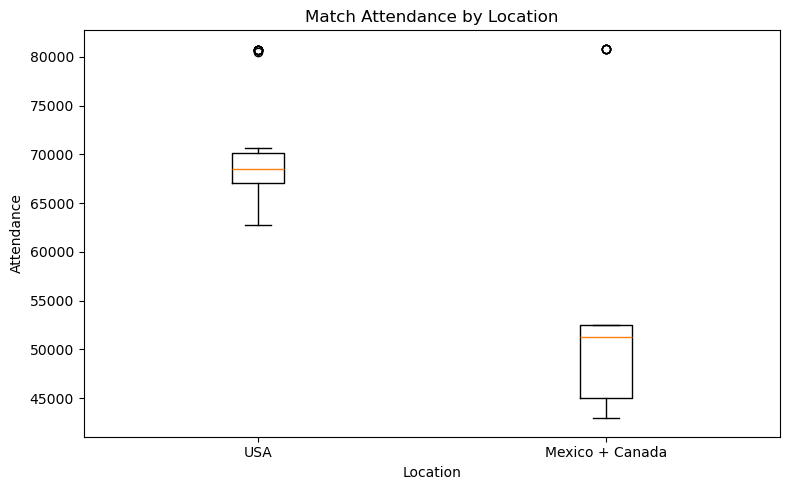

In [7]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [usa, mex_can],
    labels=["USA", "Mexico + Canada"]
)

plt.title("Match Attendance by Location")
plt.xlabel("Location")
plt.ylabel("Attendance")

plt.tight_layout()
plt.show()

## 6. Hypotheses

**H0:** There is no statistically significant difference in average attendance between USA matches and Mexico/Canada matches.

**H1:** There is a statistically significant difference in average attendance between USA matches and Mexico/Canada matches.

The significance level is set at α = 0.05.

In [8]:
alpha = 0.05

print("H0: No statistically significant difference in average attendance.")
print("H1: There is a statistically significant difference in average attendance.")
print("Significance level:", alpha)

H0: No statistically significant difference in average attendance.
H1: There is a statistically significant difference in average attendance.
Significance level: 0.05


## 7. Welch's Two-Sample t-Test

Welch's t-test is used to determine whether the average attendance differs between USA matches and Mexico/Canada matches.

Welch's t-test is used because it does not require the two groups to have equal variances.

In [9]:
t_stat, p_value = stats.ttest_ind(
    usa,
    mex_can,
    equal_var=False
)

print("Welch's t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference.")
else:
    print("Fail to reject H0: There is no statistically significant difference.")

Welch's t-statistic: 5.404
p-value: 0.0
Reject H0: There is a statistically significant difference.


## 8. Mean Difference

The difference between the average attendance of USA matches and Mexico/Canada matches is calculated.

In [10]:
mean_usa = usa.mean()
mean_mex_can = mex_can.mean()

mean_difference = mean_usa - mean_mex_can

print(f"USA mean attendance = {mean_usa:.2f}")
print(f"Mexico + Canada mean attendance = {mean_mex_can:.2f}")
print(f"Mean difference = {mean_difference:.2f}")

USA mean attendance = 69174.78
Mexico + Canada mean attendance = 54435.88
Mean difference = 14738.90


## 9. Effect Size — Cohen's d

Cohen's d measures the size of the difference between the two group means.

A small p-value indicates statistical significance, while Cohen's d helps show whether the difference is practically meaningful.

In [11]:
n1 = len(usa)
n2 = len(mex_can)

var1 = usa.var(ddof=1)
var2 = mex_can.var(ddof=1)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * var1 +
        (n2 - 1) * var2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = mean_difference / pooled_sd

print(f"Cohen's d = {cohens_d:.3f}")

if abs(cohens_d) < 0.2:
    print("Effect size: negligible")
elif abs(cohens_d) < 0.5:
    print("Effect size: small")
elif abs(cohens_d) < 0.8:
    print("Effect size: medium")
else:
    print("Effect size: large")

Cohen's d = 1.895
Effect size: large


## 10. Mann-Whitney U Test

The Mann-Whitney U test is used as a non-parametric robustness check.

This test is useful when the attendance data may not follow a normal distribution.

In [12]:
u_stat, u_p = stats.mannwhitneyu(
    usa,
    mex_can,
    alternative="two-sided"
)

print(f"Mann-Whitney U = {u_stat:.3f}")
print(f"p-value = {u_p:.4f}")

if u_p < alpha:
    print("The Mann-Whitney test indicates a statistically significant difference.")
else:
    print("The Mann-Whitney test does not indicate a statistically significant difference.")

Mann-Whitney U = 1638.000
p-value = 0.0000
The Mann-Whitney test indicates a statistically significant difference.


## 11. Difference in Means and 95% Confidence Interval

A 95% confidence interval is then constructed to quantify the uncertainty
around this estimated difference.

In [13]:
from scipy import stats
import numpy as np

diff = mean_usa - mean_mex_can
se = np.sqrt(var1/n1 + var2/n2)

# Welch-Satterthwaite degrees of freedom
df = (var1/n1 + var2/n2)**2 / (
    (var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1)
)

# 95% Confidence Interval
ci_low, ci_high = stats.t.interval(
    0.95, df, loc=diff, scale=se
)

print(f"95% CI for mean difference: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0 or ci_high < 0:
    print("The 95% confidence interval does not include zero, indicating a statistically significant difference.")
else:
    print("The 95% confidence interval includes zero, indicating no statistically significant difference.")

95% CI for mean difference: [9140.70, 20337.09]
The 95% confidence interval does not include zero, indicating a statistically significant difference.


## 12. Final Conclusion

The statistical tests are used together to determine whether attendance differs between USA matches and Mexico/Canada matches.

The Welch's t-test provides the main test of the difference in means, while the Mann-Whitney U test provides a non-parametric robustness check. Cohen's d is used to assess the practical size of the difference.

The results describe an association between match location and attendance and do not establish that match location causes differences in attendance.

In [14]:
print("=== FINAL CONCLUSION ===")

if p_value < alpha:
    print(
        "There is a statistically significant difference "
        "in average attendance between USA and Mexico/Canada matches."
    )
else:
    print(
        "There is no statistically significant difference "
        "in average attendance between USA and Mexico/Canada matches."
    )

print(f"Mean difference = {mean_difference:.2f}")
print(f"Welch's p-value = {p_value:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"Mann-Whitney p-value = {u_p:.4f}")
print(f"95% CI for mean difference: [{ci_low:.2f}, {ci_high:.2f}]")



=== FINAL CONCLUSION ===
There is a statistically significant difference in average attendance between USA and Mexico/Canada matches.
Mean difference = 14738.90
Welch's p-value = 0.0000
Cohen's d = 1.895
Mann-Whitney p-value = 0.0000
95% CI for mean difference: [9140.70, 20337.09]
